# Calculate Vegetation Indices

---

## Overview
Calculating spectral vegetation indices using `clipped_manifest.csv` per processed scene `.nc`files from `02a_preprocess_data`

1. Index Calculation Function
2. Calculate Spectral Indices 
3. Save Summary Table
3. Compare NDVI vs. NDAVI/SSSII

| Name | Description | Formula |
| --- | --- | --- | 
| NDVI | Baseline vegetation greenness | (nir - red) / (nir + red) |
| EVI | Enhanced Vegetation Index | (2.5* (nir - red) / (nir + (6)* red - (7.5)* blue +1)) |
| NDWI | Normalized Difference Water Index | (green - nir) / (green + nir) |
| NDAVI | Shallow submerged vegetation | (nir - blue) / (nir + blue) |
| SSI-II | Separating seagrass and sand | (green - red) / (green + red) |
| NDTI | Clarity or Turbidity | (red - green) / (red + green) |

---

In [1]:
# pip install...
!pip install seaborn

## Imports

In [1]:
import os
import gc
import xarray as xr 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Load Clipped Manifest

In [3]:
clipped_manifest = pd.read_csv("processed/clipped_manifest.csv", parse_dates=["date"])
clipped_manifest["tile"] = clipped_manifest["scene_id"].str.split("_").str[0]

print(f"Total scenes: {len(clipped_manifest)}")
clipped_manifest.head()

Total scenes: 145


,scene_id,level,year,date,clipped_path,tile
0,T17RNH_20151113T160052,L1C,2015,2015-11-13 16:00:52,processed/clipped\T17RNH_20151113T160052_clipp...,T17RNH
1,T17RNJ_20151113T160052,L1C,2015,2015-11-13 16:00:52,processed/clipped\T17RNJ_20151113T160052_clipp...,T17RNJ
2,T17RNH_20160302T155402,L1C,2016,2016-03-02 15:54:02,processed/clipped\T17RNH_20160302T155402_clipp...,T17RNH
3,T17RNH_20160630T160512,L1C,2016,2016-06-30 16:05:12,processed/clipped\T17RNH_20160630T160512_clipp...,T17RNH
4,T17RNH_20160720T160512,L1C,2016,2016-07-20 16:05:12,processed/clipped\T17RNH_20160720T160512_clipp...,T17RNH


## Index Calculation Function
A predefined function to calculate all spectral indices from a single scene Dataset. Returns a dictionary of spatial mean values per index to append to Dataset. 

In [4]:
def calculate_indices(ds):
    """
    Calculate spectral vegetation and water quality indices
    from Sentinel-2 bands: 
    blue = B02 , green = B03,
    red = B04 , nir = B08.
    Returns dict of mean index values.
    """
    blue, green, red, nir = ds.blue, ds.green, ds.red, ds.nir

    indices = {
        "NDVI": float(((nir - red) / (nir+ red)).mean()),
        "NDWI": float(((green -nir) / (green + nir)).mean()),
        "NDAVI": float(((nir - blue) / (nir + blue)).mean()),
        "EVI": float((2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1)).mean()),
        "SSSII": float(((green - red) / (green +red)).mean()),
        "NDTI": float(((red - green) / (red + green)).mean()),
        # Depth Invariant Index (DII) - green/blue log ratio correction for water column variation
        # log linearizes relationship between reflectance and depth
        "DII": float((np.log(green) - np.log(blue)).mean())
    }

    return indices

## Calculate Indices 
Scene by scene for loop opens each preprocessed `.nc` file with `xr.open_dataset`, calculates all indices using `calculate_indices()`, stores the spatial mean, then closes and frees from memory. Xarray's `open_dataset` was used to avoid coordinate alignment issues during stacking.

In [5]:
summary_data = []

for _, row in clipped_manifest.iterrows():
    ds = xr.open_dataset(row["clipped_path"])

    entry = {"tile_id": row["tile"], "time": row["date"]}
    entry.update(calculate_indices(ds))
    summary_data.append(entry)
    ds.close()
    gc.collect()

print(f"Processed {len(summary_data)} scenes.")

C:\Users\sulli\miniconda3\envs\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sulli\miniconda3\envs\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sulli\miniconda3\envs\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sulli\miniconda3\envs\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sulli\miniconda3\envs\myenv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\sulli\

Processed 145 scenes.


### Save Summary Table

In [6]:
summary_table = pd.DataFrame(summary_data)
summary_table["time"] = (pd.DataFrame(summary_table["time"]))
summary_table = summary_table.sort_values(["tile_id", "time"]).reset_index(drop=True)

summary_table.to_csv("processed/indices_summary.csv", index=False)
print(f"Saved: processed/indices_summary.csv")
summary_table[["tile_id", "time", "NDVI", "NDWI", "NDAVI", "EVI", "SSSII", "NDTI", "DII"]].round(4)

display(summary_table.tail(2))
display(summary_table.head(2))

Saved: processed/indices_summary.csv


C:\Users\sulli\AppData\Local\Temp\ipykernel_24552\1020761392.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  summary_table[["tile_id", "time", "NDVI", "NDWI", "NDAVI", "EVI", "SSSII", "NDTI", "DII"]].round(4)


,tile_id,time,NDVI,NDWI,NDAVI,EVI,SSSII,NDTI,DII
143,T17RNJ,2024-03-30 16:05:11,0.037500,0.065974,-0.044229,NaN,0.106635,-0.106635,NaN
144,T17RNJ,2024-11-15 16:05:11,0.051522,0.064873,-0.042059,NaN,0.120193,-0.120193,NaN


,tile_id,time,NDVI,NDWI,NDAVI,EVI,SSSII,NDTI,DII
0,T17RNH,2015-11-13 16:00:52,-0.028805,0.153598,-0.226168,NaN,0.127616,-0.127616,-0.153930
1,T17RNH,2016-03-02 15:54:02,-0.037907,0.181355,-0.248123,inf,0.147029,-0.147029,-0.142977


### NaN Check
Check for columns with all NaN values before proceeding to comparison and mapping. EVI is designed for terrestrial vegetation and frequently fails over water due to the denominator going to 0.

In [7]:
# Check number of NaNs in each column
nan_summary = summary_table.isna().sum()
print("NaN counts per index:")
print(nan_summary[nan_summary > 0])

NaN counts per index:
NDVI       1
NDWI       1
NDAVI      1
EVI      143
DII       92
dtype: int64


In [8]:
threshold = len(summary_table) * 0.75

all_nan_cols = [col for col in summary_table.columns if summary_table[col].isna().sum() > threshold]
if all_nan_cols:
    print(f"\nDropping columns with >75% NaN: {all_nan_cols}")
    summary_table = summary_table.drop(columns=all_nan_cols)
else:
    print("\nNo columns exceed 75% NaN threshold.")

print(f"\nFinal columns: {list(summary_table.columns)}")


Dropping columns with >75% NaN: ['EVI']

Final columns: ['tile_id', 'time', 'NDVI', 'NDWI', 'NDAVI', 'SSSII', 'NDTI', 'DII']


## Index Comparison: NDVI vs NDAVI vs SSSII
NDVI, NDAVI, and SSSII are all indicators of seagrass dynamics but capture different aspects:
- **NDVI (nir/red):** baseline for unsubmerged vegetation, less visibility of submerged vegetation because red light penetration is weak in water.
- **NDAVI (nir/blue):** Better visibility of submerged vegetation as blue light penetrates water better than red.
- **SSSII (green/red):** Better visible difference of seagrass from sand and spectral similarity of unsubmerged and submerged vegetation.

Divergence between indices yields useful information. For example high NDVI but low NDAVI may indicate unsubmerged vegetation beds rather than submerged. SSSII and NDVI are tide dependent, with high tides, NDVI is usually close to 0 and SSSII high, in low tides is the reverse.

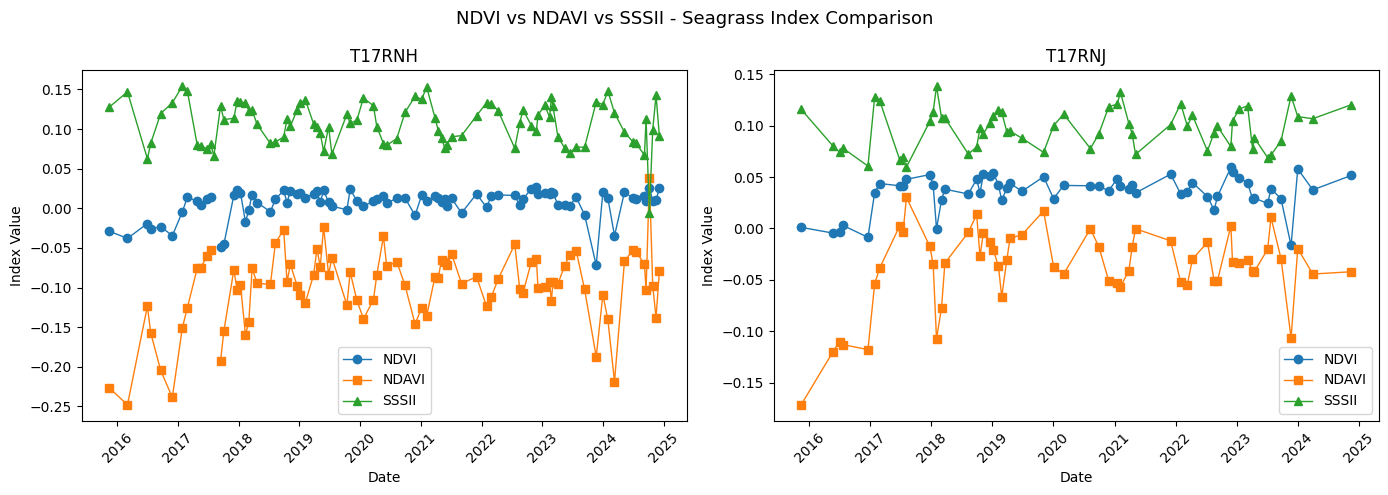

In [9]:
fig, axes = plt.subplots( 1, 2, figsize=(14, 5), sharey=False)

for ax, tile in zip(axes, summary_table["tile_id"].unique()):
    tile_df = summary_table[summary_table["tile_id"] == tile].sort_values("time")

    ax.plot(tile_df["time"], tile_df["NDVI"], label="NDVI", marker="o", linewidth=1)
    ax.plot(tile_df["time"], tile_df["NDAVI"], label="NDAVI", marker="s", linewidth=1)
    ax.plot(tile_df["time"], tile_df["SSSII"], label="SSSII", marker="^", linewidth=1)

    ax.set_title(f"{tile}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Index Value") 
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("NDVI vs NDAVI vs SSSII - Seagrass Index Comparison", fontsize=13)
plt.tight_layout()
plt.show()

### Correlation Matrix
Heat mapping of correlation coefficients between all indices to show divergence or convergence using Seaborn `sns.heatmap`. 

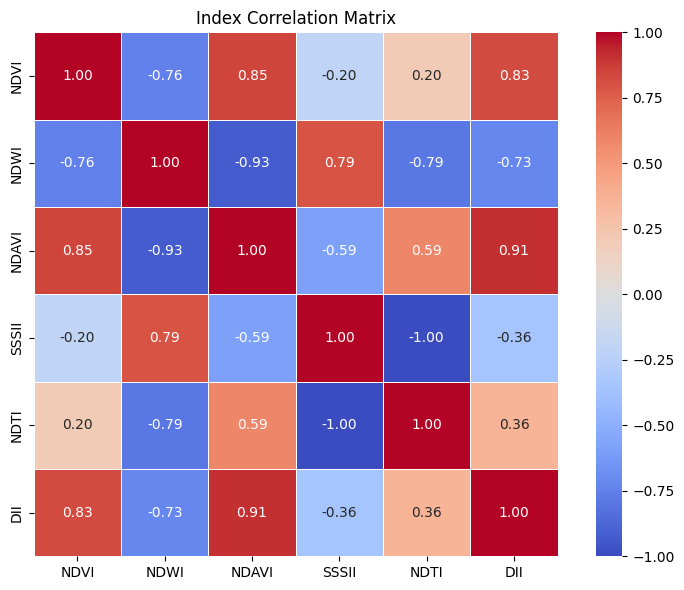

In [10]:
idx_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]
corr = summary_table[idx_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)

ax.set_title("Index Correlation Matrix")
plt.tight_layout()
plt.show()

---

## Summary
**Output:** `processed/indices_summary.csv` - Table of processed scenes with spatial mean of each index and DII values 

**Next:**`04_spatial_mapping` - to load index summary table, join with water quality data to plot spatial maps over time.

## Resources and references

 - Elshall, A. (2026). *xarray* [Environmental Data Science course notebook] FGCU.
 - Code assistance provided by Kiro AI (AWS, 2025). https://kiro.dev
 - Lai, Y., Zhou, Z., Su, B., Xuanyuan, Z., Tang, J., Yan, J., Liang, W., & Chen, J. (2022, November 11). [*Single underwater image enhancement based on differential attenuation compensation.*](https://www.frontiersin.org/journals/marine-science/articles/10.3389/fmars.2022.1047053/full) Frontiers.
 - Torrez-Perez, J. L., McCullum, A., Beaudry, B., & Cruz, S. (2023, November 2).  [*Spectral indices for land and aquatic applications part 2.*](https://appliedsciences.nasa.gov/sites/default/files/2023-10/Spectral_Indices_Part2.pdf) NASA.
 - David R. Lyzenga. Appl. Opt. 17, 379-383 (1978). [*"Passive remote sensing techniques for mapping water depth and bottom features,"*](https://opg.optica.org/ao/abstract.cfm?URI=ao-17-3-379) 
 
